# Linkage, recombination, and LOD scores

We ask one question. Do a DNA marker and a disease allele travel together through a family more often than independent assortment predicts?

This is a simplified parametric linkage example. We treat the disease-bearing chromosome and marker phase as known; a full pedigree model also specifies disease-allele frequency and penetrance.

## Start from first principles

- A meiosis transmits one parental chromosome segment.
- A marker near the disease allele usually stays on the same transmitted segment.
- The recombination fraction $\theta$ is the probability that recombination separates the two loci in an informative meiosis.
- Unlinked loci have $\theta=1/2$.
- A recombinant also marks a boundary for the chromosome region that can contain the disease allele.

This worked example connects **dominant inheritance, haplotypes, linkage, co-segregation, and recombination** with **likelihood ratios and LOD scores**.


## 1. Each meiosis gives evidence about $\theta$

Suppose marker phase is known. Among informative meioses, let $n_N$ be the number of nonrecombinant transmissions and $n_R$ the number of recombinant transmissions. Under the simplest linkage model,

$$
L(\theta)=(1-\theta)^{n_N}\theta^{n_R},\qquad 0\leq\theta\leq\frac12.
$$

The unlinked model fixes $\theta=1/2$. The LOD score compares the two models:

$$
\operatorname{LOD}(\theta)
=\log_{10}\frac{L(\theta)}{L(1/2)}.
$$

The maximum-likelihood estimate is $\widehat\theta=n_R/(n_N+n_R)$ when that value is at most $1/2$.


In [1]:
lod_score <- function(theta, nonrecombinant, recombinant) {
  if (theta < 0 || theta > 0.5) stop("theta must be between 0 and 0.5")
  n <- nonrecombinant + recombinant
  linked <- (1 - theta)^nonrecombinant * theta^recombinant
  unlinked <- 0.5^n
  log10(linked / unlinked)
}

fit_linkage <- function(nonrecombinant, recombinant) {
  n <- nonrecombinant + recombinant
  theta_hat <- min(recombinant / n, 0.5)
  data.frame(
    nonrecombinant = nonrecombinant,
    recombinant = recombinant,
    theta_hat = theta_hat,
    max_LOD = lod_score(theta_hat, nonrecombinant, recombinant)
  )
}

comparison <- rbind(
  fit_linkage(nonrecombinant = 10, recombinant = 0),
  fit_linkage(nonrecombinant = 9, recombinant = 1)
)
comparison

stopifnot(abs(lod_score(0.5, 10, 0)) < 1e-12)
stopifnot(abs(lod_score(0, 10, 0) - 10 * log10(2)) < 1e-12)


nonrecombinant,recombinant,theta_hat,max_LOD
<dbl>,<dbl>,<dbl>,<dbl>
10,0,0.0,3.010300
9,1,0.1,1.598483


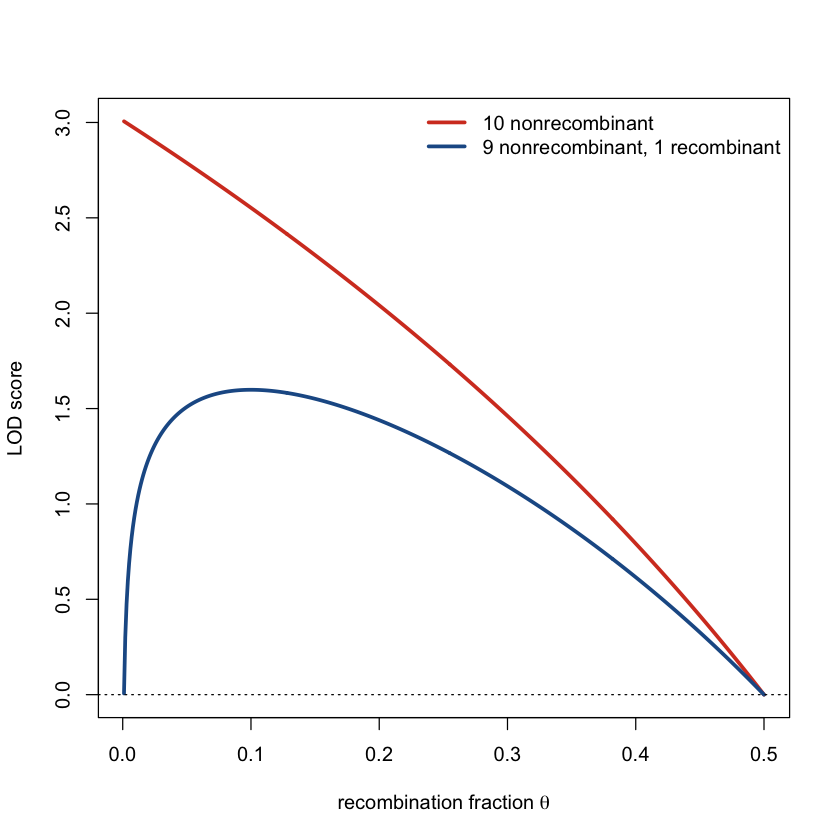

In [2]:
theta_grid <- seq(0.001, 0.5, length.out = 500)
lod_no_recombinant <- vapply(
  theta_grid, lod_score, numeric(1), nonrecombinant = 10, recombinant = 0
)
lod_one_recombinant <- vapply(
  theta_grid, lod_score, numeric(1), nonrecombinant = 9, recombinant = 1
)

plot(
  theta_grid, lod_no_recombinant,
  type = "l", lwd = 3, col = "#D43F27",
  xlab = expression("recombination fraction " * theta),
  ylab = "LOD score"
)
lines(theta_grid, lod_one_recombinant, lwd = 3, col = "#1F5A94")
abline(h = 0, lty = 3)
legend(
  "topright",
  legend = c("10 nonrecombinant", "9 nonrecombinant, 1 recombinant"),
  col = c("#D43F27", "#1F5A94"), lwd = 3, bty = "n"
)


## 2. Independent meioses add evidence

For independent meioses, likelihoods multiply. A logarithm turns that product into a sum:

$$
\frac{L_{\mathrm{all}}(\theta)}{L_{\mathrm{all}}(1/2)}
=\prod_j \frac{L_j(\theta)}{L_j(1/2)},
\qquad
\operatorname{LOD}_{\mathrm{all}}(\theta)=\sum_j\operatorname{LOD}_j(\theta).
$$

This is the methodological insight. Each informative transmission contributes evidence, and the LOD score keeps a running total on the log scale.


In [3]:
theta <- 0
lod_per_nonrecombinant <- log10((1 - theta) / 0.5)
lod_sum <- sum(rep(lod_per_nonrecombinant, 10))
lod_joint <- lod_score(theta, nonrecombinant = 10, recombinant = 0)

data.frame(
  contribution_per_meiosis = lod_per_nonrecombinant,
  sum_of_contributions = lod_sum,
  joint_LOD = lod_joint
)

stopifnot(abs(lod_sum - lod_joint) < 1e-12)


contribution_per_meiosis,sum_of_contributions,joint_LOD
<dbl>,<dbl>,<dbl>
0.30103,3.0103,3.0103


## 3. Recombinants also narrow the chromosome region

The LOD score asks whether a marker is linked to disease. Recombinant chromosomes tell us where linkage must end. In the toy family below, each affected relative carries part of the disease-associated haplotype. The overlap is the candidate region.

The positions are illustrative, not the original Huntington's disease coordinates.


candidate_left,candidate_right
<dbl>,<dbl>
20,68


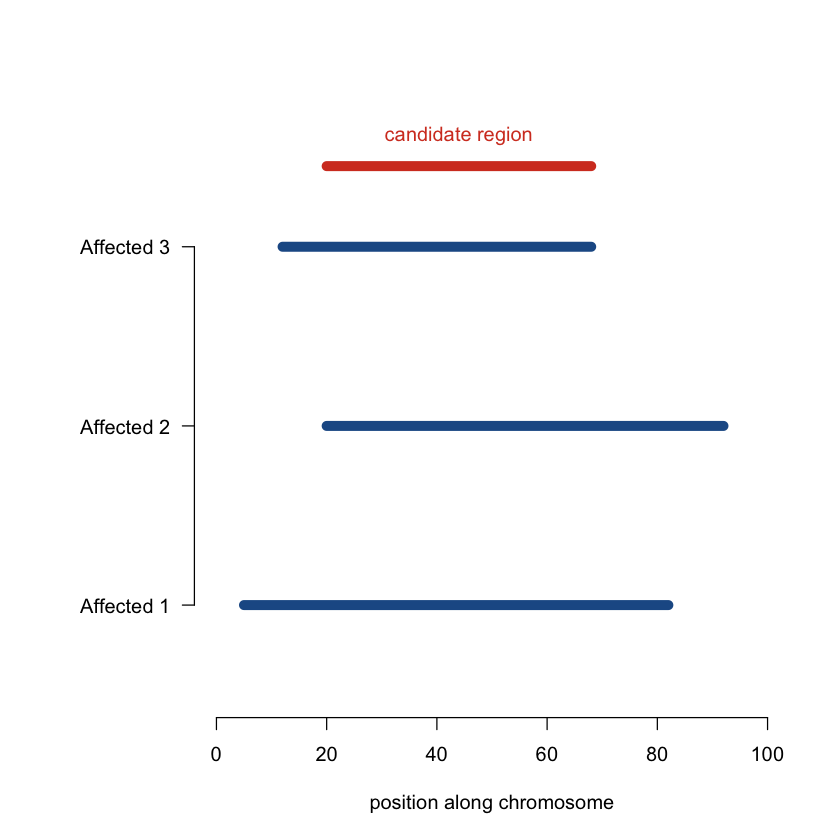

In [4]:
shared_segment <- data.frame(
  relative = c("Affected 1", "Affected 2", "Affected 3"),
  left = c(5, 20, 12),
  right = c(82, 92, 68)
)

candidate_left <- max(shared_segment$left)
candidate_right <- min(shared_segment$right)

old_par <- par(mar = c(5, 8, 4, 2) + 0.1)
plot(
  c(0, 100), c(0.5, 3.7), type = "n", axes = FALSE,
  xlab = "position along chromosome", ylab = ""
)
axis(1)
axis(2, at = 1:3, labels = shared_segment$relative, las = 1)
for (i in seq_len(nrow(shared_segment))) {
  segments(
    shared_segment$left[i], i, shared_segment$right[i], i,
    lwd = 8, col = "#1F5A94"
  )
}
segments(candidate_left, 3.45, candidate_right, 3.45, lwd = 8, col = "#D43F27")
text(
  mean(c(candidate_left, candidate_right)), 3.62,
  labels = "candidate region", col = "#D43F27"
)

data.frame(candidate_left = candidate_left, candidate_right = candidate_right)
stopifnot(candidate_left < candidate_right)
invisible(par(old_par))


## What to remember

1. **Concept and intuition.** Nearby loci tend to travel together because few recombination events occur between them.
2. **Methodological insight.** Likelihood ratios multiply across independent meioses. LOD scores add the same evidence on the log scale.
3. **Worked example.** Ten nonrecombinant meioses give a LOD score of $10\log_{10}2=3.01$. Recombinants lower the evidence for tight linkage and set candidate-region boundaries.

The calculation assumes known marker phase, a correct inheritance model, and informative meioses. Incomplete penetrance, locus heterogeneity, or pedigree error requires a richer likelihood.

## Source record and further detail

- Pritchard, *An Owner's Guide to the Human Genome*, Chapter 4.1 for the Huntington pedigree and Chapter 2.3 for linkage and recombination.
- Pritchard, Chapter 4.2, for positional cloning and major-effect mutations.
- [Gusella et al. (1983), *A polymorphic DNA marker genetically linked to Huntington's disease*](https://pubmed.ncbi.nlm.nih.gov/6316146/).
- The LOD calculations and candidate-region positions in this notebook are original teaching examples. The exact controls are $\operatorname{LOD}(1/2)=0$ and equality between the joint LOD and the sum of per-meiosis contributions.
